<h1>Automobile Exploratory Data Analysis</h1>

<h2>Context</h2>

This dataset consist of data From 1985 Ward's Automotive Yearbook

<h2>Content</h2>
This data set consists of three types of entities: <br>
(a) the specification of an auto in terms of various characteristics. <br>                                                                                  (b) its assigned insurance risk rating. <br>
    This rating corresponds to the degree to which the auto is more risky than its price indicates. Cars are initially assigned a risk factor symbol associated with its price. Then, if it is more risky (or less), this symbol is adjusted by moving it up (or down) the scale. Actuarians call this process "symboling". A value of +3 indicates that the auto is risky, -3 that it is probably pretty safe. <br>

(c) its normalized losses in use as compared to other cars. <br>
    This is the relative average loss payment per insured vehicle year. This value is normalized for all autos within a particular size classification (two-door small, station wagons, sports/speciality, etc…), and represents the average loss per car per year.

<h2>1. Import Data</h2>


In [2]:
# Import Necessary Libraries
import pandas as pd
import numpy as np

Load the data and store it in dataframe `df`


In [5]:
df = pd.read_csv("automobile.csv")
df.info()
df.sample(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized-losses  201 non-null    int64  
 2   make               201 non-null    object 
 3   aspiration         201 non-null    object 
 4   num-of-doors       201 non-null    object 
 5   body-style         201 non-null    object 
 6   drive-wheels       201 non-null    object 
 7   engine-location    201 non-null    object 
 8   wheel-base         201 non-null    float64
 9   length             201 non-null    float64
 10  width              201 non-null    float64
 11  height             201 non-null    float64
 12  curb-weight        201 non-null    int64  
 13  engine-type        201 non-null    object 
 14  num-of-cylinders   201 non-null    object 
 15  engine-size        201 non-null    int64  
 16  fuel-system        201 non

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
165,2,134,toyota,std,two,hatchback,rwd,front,98.4,0.846708,...,9.3,116.0,4800.0,24,30,9989,9.791667,Medium,0,1
0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,13495,11.190476,Medium,0,1
99,0,108,nissan,std,four,wagon,fwd,front,100.4,0.887074,...,9.0,152.0,5200.0,17,22,14399,13.823529,Medium,0,1
92,1,128,nissan,std,two,hatchback,fwd,front,94.5,0.795771,...,9.4,69.0,5200.0,31,37,7799,7.580645,Low,0,1
12,0,188,bmw,std,four,sedan,rwd,front,101.2,0.849592,...,9.0,121.0,4250.0,21,28,21105,11.190476,Medium,0,1
44,0,145,jaguar,std,four,sedan,rwd,front,113.0,0.959154,...,8.1,176.0,4750.0,15,19,32250,15.666667,High,0,1
53,3,150,mazda,std,two,hatchback,rwd,front,95.3,0.812110,...,9.4,101.0,6000.0,17,23,11845,13.823529,Low,0,1
96,0,106,nissan,std,four,hatchback,fwd,front,97.2,0.833253,...,8.5,97.0,5200.0,27,34,8949,8.703704,Low,0,1
58,1,129,mazda,std,two,hatchback,fwd,front,98.8,0.854397,...,8.6,84.0,4800.0,26,32,10595,9.038462,Low,0,1
25,1,148,dodge,std,four,sedan,fwd,front,93.7,0.755887,...,9.4,68.0,5500.0,31,38,7609,7.580645,Low,0,1


<h2>2. Understanding Data</h2>

Show what all columns are there and their data type

In [4]:
df.dtypes

symboling              int64
normalized-losses      int64
make                  object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                 float64
stroke               float64
compression-ratio    float64
horsepower           float64
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                  int64
city-L/100km         float64
horsepower-binned     object
diesel                 int64
gas                    int64
dtype: object

In [5]:
# Use Describe to get descriptive statistical summary of numberical columns
df.describe()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,diesel,gas
count,201.000000,201.00000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,197.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,0.840796,122.00000,98.797015,0.837102,0.915126,53.766667,2555.666667,126.875622,3.330692,3.256904,10.164279,103.405534,5117.665368,25.179104,30.686567,13207.129353,9.944145,0.099502,0.900498
std,1.254802,31.99625,6.066366,0.059213,0.029187,2.447822,517.296727,41.546834,0.268072,0.319256,4.004965,37.365700,478.113805,6.423220,6.815150,7947.066342,2.534599,0.300083,0.300083
min,-2.000000,65.00000,86.600000,0.678039,0.837500,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000,4.795918,0.000000,0.000000
25%,0.000000,101.00000,94.500000,0.801538,0.890278,52.000000,2169.000000,98.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000,7.833333,0.000000,1.000000
50%,1.000000,122.00000,97.000000,0.832292,0.909722,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5125.369458,24.000000,30.000000,10295.000000,9.791667,0.000000,1.000000
75%,2.000000,137.00000,102.400000,0.881788,0.925000,55.500000,2926.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000,12.368421,0.000000,1.000000
max,3.000000,256.00000,120.900000,1.000000,1.000000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,262.000000,6600.000000,49.000000,54.000000,45400.000000,18.076923,1.000000,1.000000


What are the fill rates of Categorical Data? i.e. what all values are there and how is the distribution of data for each of the categorical data.

<Axes: xlabel='gas'>

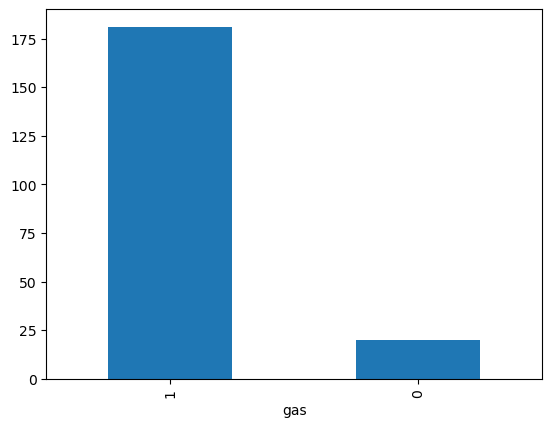

In [18]:
#df['make'].value_counts().plot(kind='bar')

#df['aspiration'].value_counts().plot(kind='bar')
#df['num-of-doors'].value_counts().plot(kind='bar')
#df['body-style'].value_counts().plot(kind='bar')
#df['drive-wheels'].value_counts().plot(kind='bar')
#df['engine-location'].value_counts().plot(kind='bar')
#df['engine-type'].value_counts().plot(kind='bar')
#df['num-of-cylinders'].value_counts().plot(kind='bar')
#df['fuel-system'].value_counts().plot(kind='bar')
#df['horsepower-binned'].value_counts().plot(kind='bar')
#df['diesel'].value_counts().plot(kind='bar')
df['gas'].value_counts().plot(kind='bar')


<h2>3. Check For Nulls </h2>

In [19]:
df.isna().sum()

symboling            0
normalized-losses    0
make                 0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               4
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
city-L/100km         0
horsepower-binned    1
diesel               0
gas                  0
dtype: int64

In [20]:
df.dropna(inplace=True)
df['make'].count()

np.int64(196)

In [21]:
df.isna().sum()

symboling            0
normalized-losses    0
make                 0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
city-L/100km         0
horsepower-binned    0
diesel               0
gas                  0
dtype: int64

<h2>4. Trying to Understand relation between various Numerical attributes</h2>


In [22]:
# Derive Correlation of each numerical attributes
df_corr = df.corr(numeric_only=True)
df_corr


,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,diesel,gas
symboling,1.000000,0.453423,-0.533112,-0.359883,-0.242821,-0.539407,-0.226121,-0.055329,-0.142125,-0.013520,-0.180275,0.090778,0.229436,0.004688,0.073359,-0.076420,0.021612,-0.192544,0.192544
normalized-losses,0.453423,1.000000,-0.046971,0.027234,0.090056,-0.362499,0.107034,0.147862,-0.030152,0.056054,-0.112288,0.226654,0.215903,-0.208695,-0.166772,0.138183,0.223308,-0.096487,0.096487
wheel-base,-0.533112,-0.046971,1.000000,0.876945,0.821427,0.607417,0.790205,0.592517,0.493941,0.163725,0.248383,0.381984,-0.351925,-0.496565,-0.566948,0.591956,0.517050,0.305889,-0.305889
length,-0.359883,0.027234,0.876945,1.000000,0.857249,0.522367,0.882091,0.698626,0.608496,0.136850,0.156926,0.583073,-0.280397,-0.686142,-0.715124,0.689466,0.690579,0.212484,-0.212484
width,-0.242821,0.090056,0.821427,0.857249,1.000000,0.351127,0.862835,0.739543,0.543859,0.210495,0.188331,0.604099,-0.252116,-0.639692,-0.684550,0.744176,0.685663,0.251112,-0.251112
height,-0.539407,-0.362499,0.607417,0.522367,0.351127,1.000000,0.354085,0.100518,0.199490,-0.084755,0.269773,-0.031489,-0.270020,-0.128523,-0.181670,0.182407,0.111120,0.279063,-0.279063
curb-weight,-0.226121,0.107034,0.790205,0.882091,0.862835,0.354085,1.000000,0.858968,0.646918,0.193575,0.153952,0.750749,-0.281231,-0.766146,-0.808146,0.828483,0.809512,0.228445,-0.228445
engine-size,-0.055329,0.147862,0.592517,0.698626,0.739543,0.100518,0.858968,1.000000,0.601384,0.265626,0.017246,0.825377,-0.227577,-0.712693,-0.734062,0.889265,0.814696,0.076032,-0.076032
bore,-0.142125,-0.030152,0.493941,0.608496,0.543859,0.199490,0.646918,0.601384,1.000000,-0.049606,-0.000044,0.579114,-0.276668,-0.591597,-0.598455,0.544375,0.574286,0.055927,-0.055927
stroke,-0.013520,0.056054,0.163725,0.136850,0.210495,-0.084755,0.193575,0.265626,-0.049606,1.000000,0.191776,0.139409,-0.067852,-0.050971,-0.052345,0.107893,0.065893,0.240193,-0.240193


Understanding Correlation using a heatmap

<Axes: >

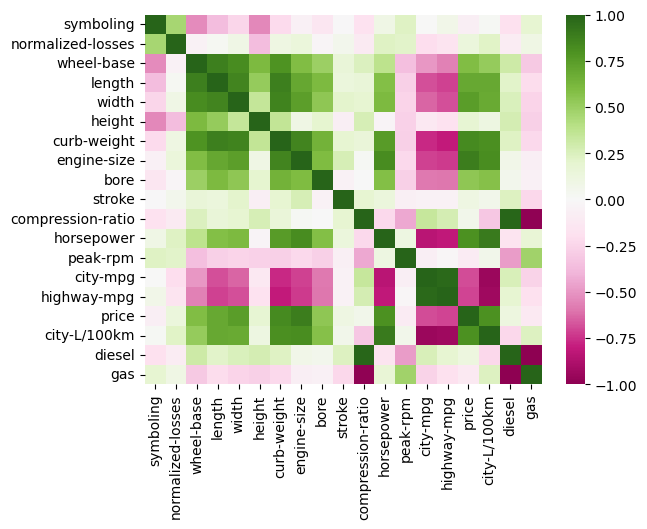

In [23]:
#import matplotlib.pyplot as plt
import seaborn as sns
#%matplotlib inline
sns.heatmap(df_corr,cmap="PiYG")

In Order to understand various factors that affect the price of the automobile one simple way is verify the linear relationship between price and other chracteristics.


<Axes: xlabel='engine-size', ylabel='price'>

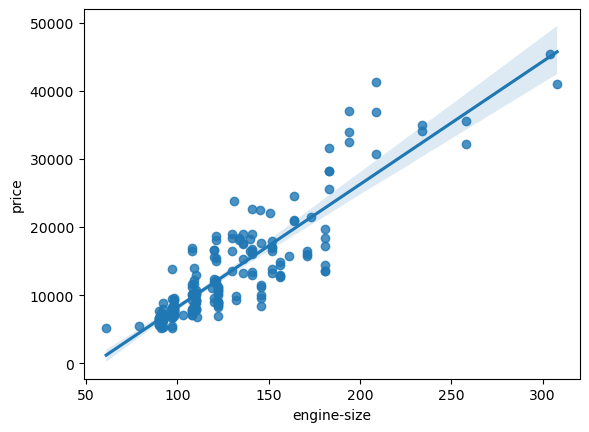

In [24]:
sns.regplot(x="engine-size", y="price", data=df)


<Axes: xlabel='horsepower', ylabel='price'>

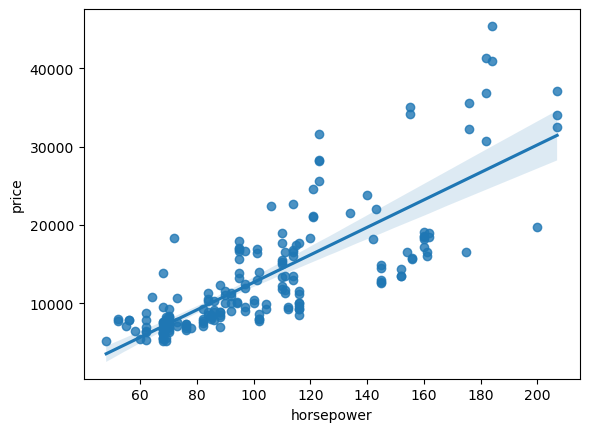

In [26]:
# See if horsepower has linearly related to price
sns.regplot(x="horsepower", y="price", data=df)

<Axes: xlabel='city-mpg', ylabel='price'>

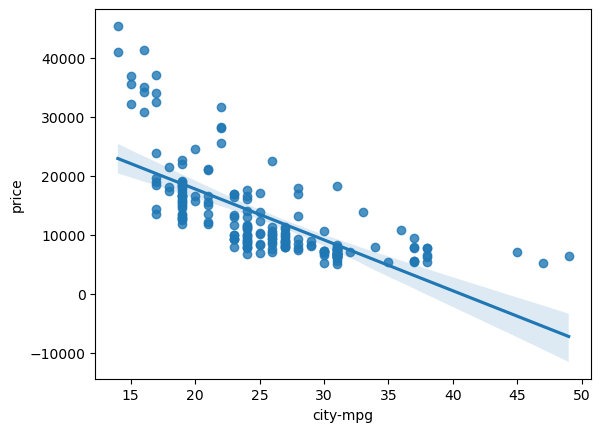

In [28]:
# Example of Negative Correlation
sns.regplot(x="city-mpg", y="price", data=df)


Some variables does not have either +ve or -ve correlation and hence not much useful for assessing the price like "peak-rpm"


<Axes: xlabel='peak-rpm', ylabel='price'>

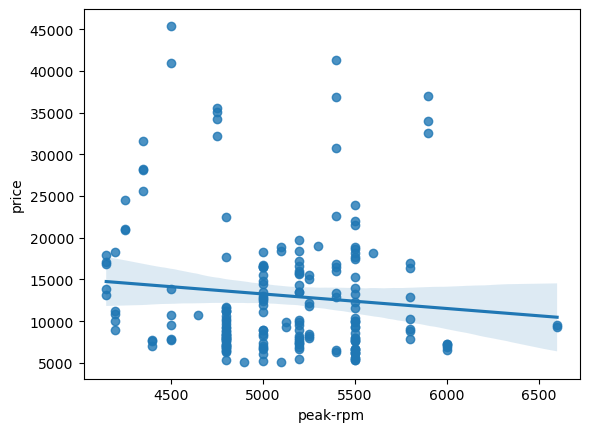

In [29]:
sns.regplot(x="peak-rpm", y="price", data=df)

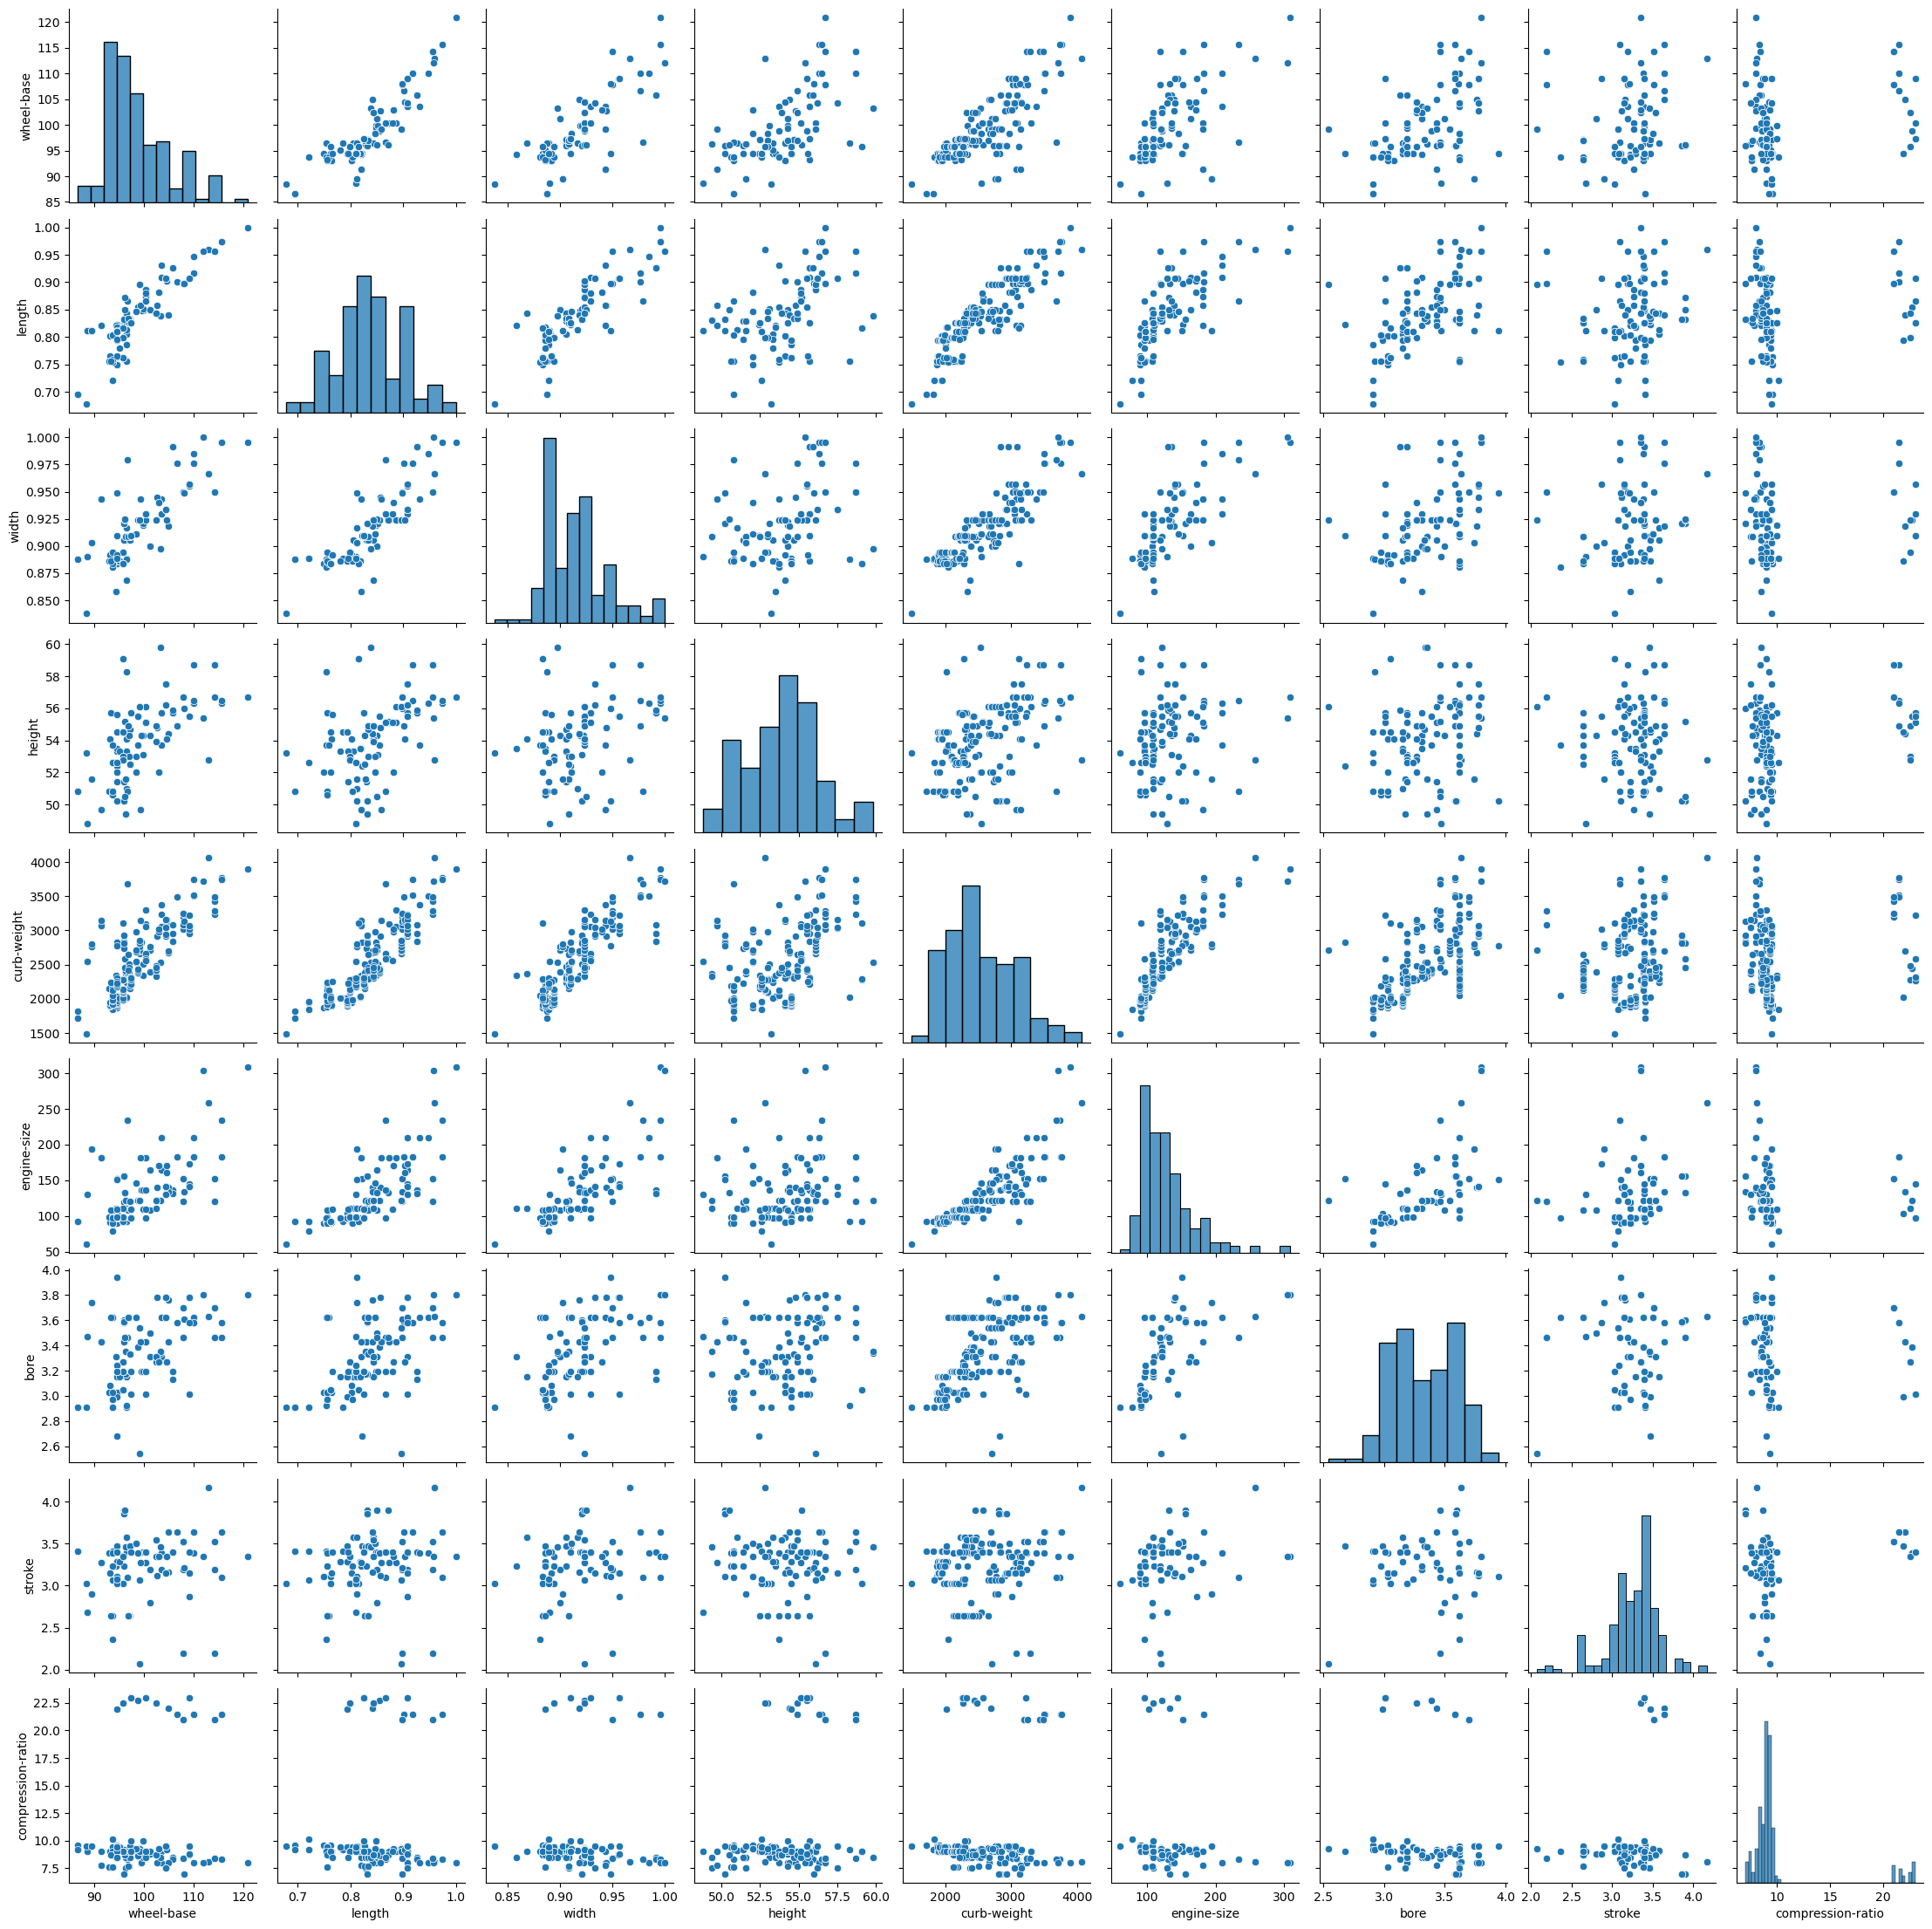

In [44]:
#penguins = sns.load_dataset("penguins")
#penguins.info()
sns.pairplot(df.iloc[:,5:20])

<h2>5. Understanding Categorical attributes</h2>

<Axes: xlabel='body-style', ylabel='price'>

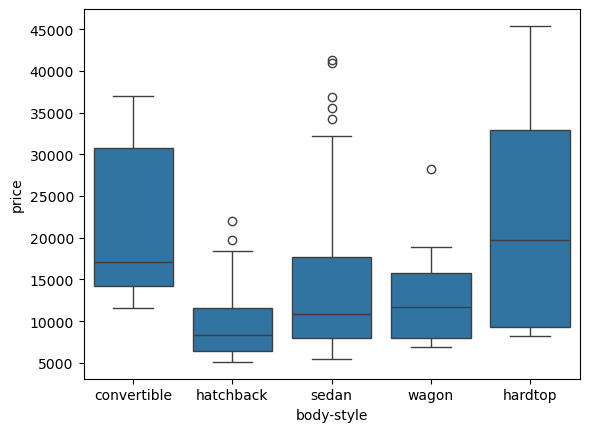

In [30]:
# See if body-style relates to the car price 
sns.boxplot(x="body-style", y="price", data=df)

<p>Here we see that the distributions of price between the different body-style categories have a significant overlap, so body-style would not be a good predictor of price.</p>


<p>Does engine location has any significance</p>


<Axes: xlabel='engine-location', ylabel='price'>

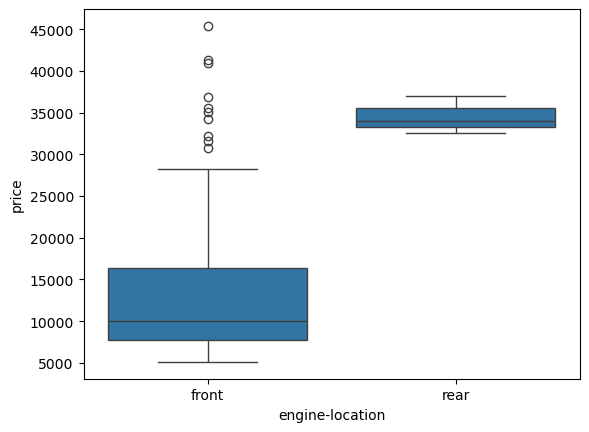

In [31]:
sns.boxplot(x="engine-location", y="price", data=df)

<p>Here we see that the distribution of price between these two engine-location categories, are widely separated enough to take engine-location as a potential good predicting price.</p>


Now we will check "drive-wheels" and "price".


<Axes: xlabel='drive-wheels', ylabel='price'>

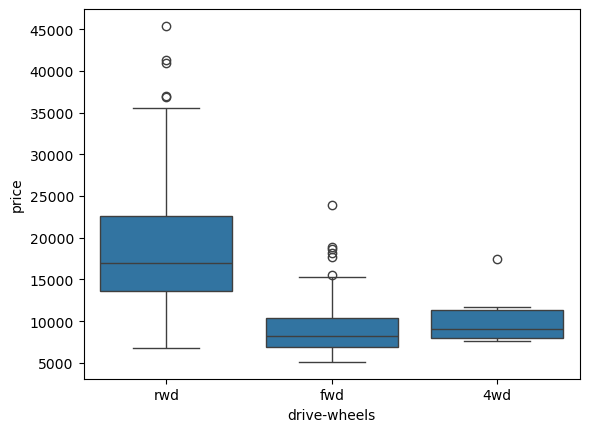

In [32]:
# drive-wheels
sns.boxplot(x="drive-wheels", y="price", data=df)

<p>Here also see that the distribution of price between the different drive-wheels categories vary to a certain extent.
    So drive-wheels is also good indicator of price</p>


<h2 >6. Data Aggregation and Pivot</h2>


In [33]:
df['drive-wheels'].unique()

array(['rwd', 'fwd', '4wd'], dtype=object)

<p>If we want to know, on average, which type of drive wheel is most valuable, we can group "drive-wheels" and then average them.</p>

<p>We can select the columns 'drive-wheels', 'body-style' and 'price', then assign it to the variable "df_group_one".</p>


In [31]:
df_group_one = df[['drive-wheels','body-style','price']]
df_group_one

,drive-wheels,body-style,price
0,rwd,convertible,13495
1,rwd,convertible,16500
2,rwd,hatchback,16500
3,fwd,sedan,13950
4,4wd,sedan,17450
...,...,...,...
196,rwd,sedan,16845
197,rwd,sedan,19045
198,rwd,sedan,21485
199,rwd,sedan,22470


We can then calculate the average price for each of the different categories of data.


In [32]:
# grouping results
df_group_one = df_group_one.groupby(['drive-wheels'],as_index=False).mean(numeric_only=True)
df_group_one

,drive-wheels,price
0,4wd,10241.000000
1,fwd,9244.779661
2,rwd,19910.585714


<p>We can see that rear-wheel drive vehicles on average is the most expensive, while 4-wheel and front-wheel are more or less have the same price.</p>

<p>Now lets see both 'drive-wheels' and 'body-style'. This groups the dataframe by the unique combination of 'drive-wheels' and 'body-style'.</p>


In [34]:
# grouping results
df_gptest = df[['drive-wheels','body-style','price']]
grouped_test1 = df_gptest.groupby(['drive-wheels','body-style'],as_index=False).mean(numeric_only=True)
grouped_test1

,drive-wheels,body-style,price
0,4wd,hatchback,7603.000000
1,4wd,sedan,12647.333333
2,4wd,wagon,9095.750000
3,fwd,convertible,11595.000000
4,fwd,hardtop,8249.000000
5,fwd,hatchback,8396.387755
6,fwd,sedan,9811.800000
7,fwd,wagon,9997.333333
8,rwd,convertible,23949.600000
9,rwd,hardtop,24202.714286


<p>A better way to represent above data is using Pivot which is used in excel</p>


In [35]:
grouped_pivot = grouped_test1.pivot(index='drive-wheels',columns='body-style')
grouped_pivot

price                                            \
body-style   convertible       hardtop     hatchback         sedan   
drive-wheels                                                         
4wd                  NaN           NaN   7603.000000  12647.333333   
fwd              11595.0   8249.000000   8396.387755   9811.800000   
rwd              23949.6  24202.714286  14714.285714  21303.600000   

                            
body-style           wagon  
drive-wheels                
4wd            9095.750000  
fwd            9997.333333  
rwd           16994.222222

<p>Often, we won't have data for some of the pivot cells. We can fill these missing cells with the value 0, but any other value could potentially be used as well. </p>


In [36]:
grouped_pivot = grouped_pivot.fillna(0) #fill missing values with 0
grouped_pivot

price                                            \
body-style   convertible       hardtop     hatchback         sedan   
drive-wheels                                                         
4wd                  0.0      0.000000   7603.000000  12647.333333   
fwd              11595.0   8249.000000   8396.387755   9811.800000   
rwd              23949.6  24202.714286  14714.285714  21303.600000   

                            
body-style           wagon  
drive-wheels                
4wd            9095.750000  
fwd            9997.333333  
rwd           16994.222222

<p>We now have a better idea of what our data looks like and which variables are important to take into account for modeling.</p>